# NB2 — SegFormer-B0  ·  `seg-segformer-b0`

**Course:** CSE 438 — Digital Image Processing · **Dept.** of CSE, East West University · **Term:** Summer 2026
**Instructor:** _`<fill instructor>`_ · **Group:** _`<fill group>`_

| # | Name | Student ID |
|---|---|---|
| 1 | MD. Asif Hossain | 2022-3-60-007 |
| 2 | _`<member 2>`_ | _`<id>`_ |
| 3 | _`<member 3>`_ | _`<id>`_ |
| 4 | _`<member 4>`_ | _`<id>`_ |

**Dataset:** PaveCrack1300 (1,300 UAV pavement patches · 512×512 · binary background/crack).
**This notebook:** loads the **leakage-safe split from NB0**, trains **SegFormer-B0** for ≥50 epochs
(Task E), evaluates on the held-out test set (Task F), and does error analysis (Task G).

> **Fairness contract:** NB1 and NB2 use an **identical** data/loss/metric/training pipeline. Only the
> model-definition cell differs. Optimizer, LR, schedule, weight-decay, batch size, epochs, loss and the
> checkpoint metric are the same across both — so the benchmark is apples-to-apples.

**Internal order (per assignment §4):** 1 setup · 2 load split · 3 model · 4 config cell · 5 training +
curves · 6 test metrics (Task F) · 7 error analysis (Task G) · 8 summary + append to `results.json`.

### Before you run
Attach **two** inputs via **+ Add Input**: (1) the raw **PaveCrack1300** dataset, and (2) the **committed
output of NB0** (which carries `split.json` + `class_weights.json`). Turn the **GPU on** (T4). Then Run All.

## 1 · Setup & imports (version-pinned)

In [1]:
import os, glob, json, time, random, warnings, math
from pathlib import Path
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
warnings.filterwarnings("ignore")

try:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
except Exception:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "albumentations"], check=False)
    import albumentations as A
    from albumentations.pytorch import ToTensorV2

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", DEVICE, "| albumentations", A.__version__)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

SEED = 42
def seed_everything(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
seed_everything()

torch 2.10.0+cu128 | device: cuda | albumentations 2.0.8
GPU: Tesla T4


## 2 · Load the shared split from NB0 (name-agnostic)
We locate `split.json` and `class_weights.json` with a recursive glob (so it works regardless of the exact
attached-dataset name), then rebuild absolute image/mask paths from the raw dataset. **We never re-split** —
using NB0's exact split is what makes the three-model comparison fair.

In [2]:
def _find(pattern):
    hits = glob.glob(pattern, recursive=True)
    return hits[0] if hits else None

split_path = _find("/kaggle/input/**/split.json")
cw_path    = _find("/kaggle/input/**/class_weights.json")
assert split_path, "split.json not found — attach the committed NB0 output via + Add Input."
split = json.load(open(split_path))
print("loaded split from:", split_path)
print("counts:", split["counts"], "| classes:", split["class_names"], "| seed:", split["seed"])

NUM_CLASSES = split["num_classes"]
CLASS_NAMES = split["class_names"]
IMG_SIZE    = split["img_size"]

# class weights (fall back to uniform if the file is missing)
if cw_path:
    CLASS_WEIGHTS = json.load(open(cw_path))["ce_weights"]
else:
    CLASS_WEIGHTS = [1.0] * NUM_CLASSES
print("CE class weights:", dict(zip(CLASS_NAMES, [round(w,3) for w in CLASS_WEIGHTS])))

# rebuild absolute paths from the raw dataset
IMGS  = glob.glob("/kaggle/input/**/images/images/*.jpg", recursive=True) or \
        glob.glob("/kaggle/input/**/images/**/*.jpg", recursive=True)
MASKS = glob.glob("/kaggle/input/**/masks/**/*.png", recursive=True)
PATH_BY_NAME = {Path(p).name: p for p in IMGS}
MASK_BY_NAME = {Path(p).name: p for p in MASKS}
assert PATH_BY_NAME and MASK_BY_NAME, "raw PaveCrack1300 images/masks not found — attach the dataset."
print("resolved", len(PATH_BY_NAME), "images,", len(MASK_BY_NAME), "masks from raw dataset")

loaded split from: /kaggle/input/datasets/alptagin/nb0-eda-and-data-preparation-data/split.json
counts: {'train': 909, 'val': 195, 'test': 196} | classes: ['background', 'crack'] | seed: 42
CE class weights: {'background': 0.561, 'crack': 4.632}
resolved 1300 images, 1300 masks from raw dataset


## 3 · Data pipeline — augmentation + `Dataset` (identical to the other model notebook)
Train augmentation is **train-only** and **synchronized** (one `A.Compose` on image+mask); val/test get only
Normalize+ToTensor. This is the same pipeline defined and sanity-checked in NB0.

In [3]:
IMAGENET_MEAN = (0.485, 0.456, 0.406); IMAGENET_STD = (0.229, 0.224, 0.225)

def _try(cls, *variants):
    last = None
    for kw in variants:
        try: return cls(**kw)
        except (TypeError, ValueError) as e: last = e
    raise RuntimeError(f"could not build {cls.__name__}: {last}")

def _gauss_noise(p=0.2):
    return _try(A.GaussNoise, dict(std_range=(0.03, 0.12), p=p), dict(var_limit=(5.0, 30.0), p=p))

def _geom(p=0.5):
    if hasattr(A, "ShiftScaleRotate"):
        try:
            return A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=15,
                                      border_mode=cv2.BORDER_REFLECT_101, p=p)
        except (TypeError, ValueError): pass
    return _try(A.Affine,
                dict(translate_percent=0.0625, scale=(0.9,1.1), rotate=(-15,15),
                     border_mode=cv2.BORDER_REFLECT_101, p=p),
                dict(translate_percent=0.0625, scale=(0.9,1.1), rotate=(-15,15),
                     mode=cv2.BORDER_REFLECT_101, p=p),
                dict(translate_percent=0.0625, scale=(0.9,1.1), rotate=(-15,15), p=p))

train_aug = A.Compose([
    A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5), A.RandomRotate90(p=0.5), _geom(0.5),
    A.RandomBrightnessContrast(0.2, 0.2, p=0.5), A.RandomGamma((80,120), p=0.3),
    _gauss_noise(0.2), A.GaussianBlur(blur_limit=(3,5), p=0.2),
    A.Normalize(IMAGENET_MEAN, IMAGENET_STD), ToTensorV2(),
])
eval_aug = A.Compose([A.Normalize(IMAGENET_MEAN, IMAGENET_STD), ToTensorV2()])

class CrackDataset(Dataset):
    def __init__(self, records, augment):
        self.records, self.augment = records, augment
    def __len__(self): return len(self.records)
    def __getitem__(self, idx):
        r = self.records[idx]
        img = np.array(Image.open(PATH_BY_NAME[r["image"]]).convert("RGB"))
        msk = (np.array(Image.open(MASK_BY_NAME[r["mask"]])) > 0).astype("uint8")  # 255->1
        out = self.augment(image=img, mask=msk)
        return out["image"], out["mask"].long(), r["sample_id"]

BATCH_SIZE = 8  # (set in CONFIG below; defined here so loaders can be built)
train_ds = CrackDataset(split["train"], train_aug)
val_ds   = CrackDataset(split["val"],   eval_aug)
test_ds  = CrackDataset(split["test"],  eval_aug)
print("datasets:", len(train_ds), "train /", len(val_ds), "val /", len(test_ds), "test")

datasets: 909 train / 195 val / 196 test


## 4 · Metrics & loss (identical across models)
One **confusion matrix is the single source of truth** for every Task-F metric (mIoU, per-class IoU, pixel
accuracy, mean pixel accuracy, Dice). The loss is **Dice + class-weighted Cross-Entropy** — Dice optimizes
minority-class overlap directly, the light CE weight (crack≈4.6 from NB0) improves recall without gradient
spikes.

In [4]:
class ConfMat:
    def __init__(self, n): self.n = n; self.mat = torch.zeros(n, n, dtype=torch.int64)
    def update(self, pred, tgt):
        pred = pred.flatten(); tgt = tgt.flatten()
        k = (tgt >= 0) & (tgt < self.n)
        self.mat += torch.bincount(self.n * tgt[k] + pred[k], minlength=self.n**2).reshape(self.n, self.n).cpu()
    def compute(self):
        m = self.mat.double(); tp = m.diag(); fp = m.sum(0) - tp; fn = m.sum(1) - tp
        iou  = tp / (tp + fp + fn).clamp(min=1e-9)
        dice = 2*tp / (2*tp + fp + fn).clamp(min=1e-9)
        return dict(iou=iou.tolist(), miou=iou.mean().item(),
                    dice=dice.tolist(), mdice=dice.mean().item(),
                    pixel_acc=(tp.sum()/m.sum().clamp(min=1e-9)).item(),
                    mean_pixel_acc=(tp/m.sum(1).clamp(min=1e-9)).mean().item())

def per_image_iou(pred, tgt, cls=1):
    p = (pred == cls); t = (tgt == cls)
    inter = (p & t).sum().item(); union = (p | t).sum().item()
    return inter/union if union > 0 else float("nan")

class DiceLoss(nn.Module):
    def __init__(self, eps=1e-6): super().__init__(); self.eps = eps
    def forward(self, logits, target):
        probs = torch.softmax(logits, 1)
        oh = F.one_hot(target, probs.shape[1]).permute(0,3,1,2).float()
        dims = (0,2,3)
        inter = (probs*oh).sum(dims); denom = (probs+oh).sum(dims)
        dice = (2*inter + self.eps) / (denom + self.eps)
        return 1 - dice.mean()

class ComboLoss(nn.Module):
    def __init__(self, weights):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32))
        self.dice = DiceLoss()
    def forward(self, logits, target):
        return self.ce(logits, target) + self.dice(logits, target)
print("metrics + loss defined.")

metrics + loss defined.


## 5 · Model — SegFormer-B0 (HuggingFace, ADE20K-pretrained)
We load `nvidia/segformer-b0-finetuned-ade-512-512` with `num_labels=NUM_CLASSES` and
`ignore_mismatched_sizes=True` — this keeps the pretrained MiT-B0 encoder + All-MLP decoder and **re-initializes
only the final classifier** to our 2 classes (its ADE20K head predicted 150). SegFormer emits logits at **¼
resolution** `[B,C,128,128]`, so we `F.interpolate` back to 512 in the dataloader-independent `infer_logits`.
We **compute our own loss** (Dice+CE) on the upsampled logits rather than passing `labels=` — so the loss is
identical to the DeepLab notebook.

In [5]:
from transformers import SegformerForSemanticSegmentation

def build_model(num_classes):
    return SegformerForSemanticSegmentation.from_pretrained(
        "nvidia/segformer-b0-finetuned-ade-512-512",
        num_labels=num_classes, ignore_mismatched_sizes=True)

def infer_logits(model, images):
    logits = model(pixel_values=images).logits            # [B,C,H/4,W/4]
    return F.interpolate(logits, size=images.shape[-2:], mode="bilinear", align_corners=False)

def train_forward(model, images, masks, criterion):
    logits = infer_logits(model, images)
    return criterion(logits, masks), logits

MODEL_NICE = "SegFormer-B0"
print("model seam ready:", MODEL_NICE)

model seam ready: SegFormer-B0


## 6 · Training configuration — single visible config cell (Task E requirement)
Every hyperparameter lives here. These values are **identical** in the DeepLabV3 and SegFormer notebooks.

In [6]:
CONFIG = dict(
    model            = MODEL_NICE,
    num_classes      = NUM_CLASSES,
    input_size       = IMG_SIZE,
    batch_size       = 8,
    epochs           = 50,                 # minimum floor; extend if val still improving
    optimizer        = "AdamW",
    lr               = 1e-4,               # safe for both a CNN and a transformer encoder
    weight_decay     = 1e-2,               # UNIFIED across models (fairness)
    scheduler        = "LinearLR warmup(3) -> CosineAnnealing",
    warmup_epochs    = 3,
    loss             = "Dice + class-weighted CE",
    class_weights    = [round(w,3) for w in CLASS_WEIGHTS],
    amp              = True,
    tta              = "hflip (test only)",
    ckpt_metric      = "val crack-class IoU",
    seed             = SEED,
)
BATCH_SIZE = CONFIG["batch_size"]; EPOCHS = CONFIG["epochs"]
WORK = Path("/kaggle/working"); WORK.mkdir(exist_ok=True)
for k, v in CONFIG.items(): print(f"  {k:16s}: {v}")

pin = (DEVICE == "cuda")
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=pin, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=pin)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=pin)

  model           : SegFormer-B0
  num_classes     : 2
  input_size      : 512
  batch_size      : 8
  epochs          : 50
  optimizer       : AdamW
  lr              : 0.0001
  weight_decay    : 0.01
  scheduler       : LinearLR warmup(3) -> CosineAnnealing
  warmup_epochs   : 3
  loss            : Dice + class-weighted CE
  class_weights   : [0.561, 4.632]
  amp             : True
  tta             : hflip (test only)
  ckpt_metric     : val crack-class IoU
  seed            : 42


## 7 · Training (≥50 epochs) with per-epoch loss & mIoU curves
AdamW + AMP, `LinearLR` warmup for 3 epochs then cosine annealing. Each epoch we compute validation loss and
the full metric set, and **checkpoint the epoch with the best validation crack-class IoU** (not mIoU, which is
dominated by the easy background class). A 1-epoch quick pass is fine to eyeball before committing the long run.

In [7]:
model = build_model(NUM_CLASSES).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())/1e6
criterion = ComboLoss(CLASS_WEIGHTS).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
warm = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, total_iters=CONFIG["warmup_epochs"])
cos  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, EPOCHS - CONFIG["warmup_epochs"]))
scheduler = torch.optim.lr_scheduler.SequentialLR(optimizer, [warm, cos], milestones=[CONFIG["warmup_epochs"]])

try:
    from torch.amp import autocast, GradScaler
    mk_ac = lambda: autocast("cuda", enabled=(DEVICE=="cuda")); scaler = GradScaler("cuda", enabled=(DEVICE=="cuda"))
except Exception:
    from torch.cuda.amp import autocast as _ac, GradScaler as _GS
    mk_ac = lambda: _ac(enabled=(DEVICE=="cuda")); scaler = _GS(enabled=(DEVICE=="cuda"))

@torch.no_grad()
def evaluate(loader):
    model.eval(); cm = ConfMat(NUM_CLASSES); loss_sum = ntot = 0
    for images, masks, _ in loader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        with mk_ac():
            logits = infer_logits(model, images); loss = criterion(logits, masks)
        loss_sum += loss.item()*images.size(0); ntot += images.size(0)
        cm.update(logits.argmax(1), masks)
    met = cm.compute(); met["loss"] = loss_sum/max(ntot,1); met["crack_iou"] = met["iou"][1]
    return met

hist = defaultdict(list); best_ck = -1; best_path = WORK/"best.pt"; t0 = time.time()
for epoch in range(1, EPOCHS+1):
    model.train(); run = 0.0
    for images, masks, _ in train_loader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        with mk_ac():
            loss, _ = train_forward(model, images, masks, criterion)
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        run += loss.item()*images.size(0)
    scheduler.step()
    tr_loss = run/len(train_ds); vm = evaluate(val_loader)
    hist["train_loss"].append(tr_loss); hist["val_loss"].append(vm["loss"])
    hist["val_miou"].append(vm["miou"]); hist["val_crack_iou"].append(vm["crack_iou"])
    hist["lr"].append(optimizer.param_groups[0]["lr"])
    flag = ""
    if vm["crack_iou"] > best_ck:
        best_ck = vm["crack_iou"]; best_epoch = epoch
        torch.save({"model": model.state_dict(), "epoch": epoch, "val": vm, "config": CONFIG}, best_path); flag = "  <= best"
    print(f"ep {epoch:02d}/{EPOCHS} | train {tr_loss:.4f} | val {vm['loss']:.4f} | "
          f"mIoU {vm['miou']:.4f} | crackIoU {vm['crack_iou']:.4f}{flag}")
train_min = (time.time()-t0)/60
print(f"\nTraining done in {train_min:.1f} min | best val crack-IoU {best_ck:.4f} @ epoch {best_epoch}")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([2, 256, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([2])                      

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


ep 01/50 | train 1.1466 | val 0.9075 | mIoU 0.6108 | crackIoU 0.3867  <= best
ep 02/50 | train 0.7578 | val 0.5988 | mIoU 0.6842 | crackIoU 0.4798  <= best
ep 03/50 | train 0.5840 | val 0.4981 | mIoU 0.6934 | crackIoU 0.4963  <= best
ep 04/50 | train 0.4979 | val 0.4249 | mIoU 0.7642 | crackIoU 0.5963  <= best
ep 05/50 | train 0.4412 | val 0.4100 | mIoU 0.7306 | crackIoU 0.5498
ep 06/50 | train 0.4307 | val 0.3768 | mIoU 0.7721 | crackIoU 0.6111  <= best
ep 07/50 | train 0.4028 | val 0.3811 | mIoU 0.7691 | crackIoU 0.6063
ep 08/50 | train 0.3907 | val 0.3733 | mIoU 0.7676 | crackIoU 0.6043
ep 09/50 | train 0.3805 | val 0.3604 | mIoU 0.7769 | crackIoU 0.6187  <= best
ep 10/50 | train 0.3673 | val 0.3463 | mIoU 0.7890 | crackIoU 0.6382  <= best
ep 11/50 | train 0.3652 | val 0.3512 | mIoU 0.7604 | crackIoU 0.5952
ep 12/50 | train 0.3574 | val 0.3571 | mIoU 0.7853 | crackIoU 0.6313
ep 13/50 | train 0.3492 | val 0.3555 | mIoU 0.7554 | crackIoU 0.5875
ep 14/50 | train 0.3471 | val 0.3375 | m

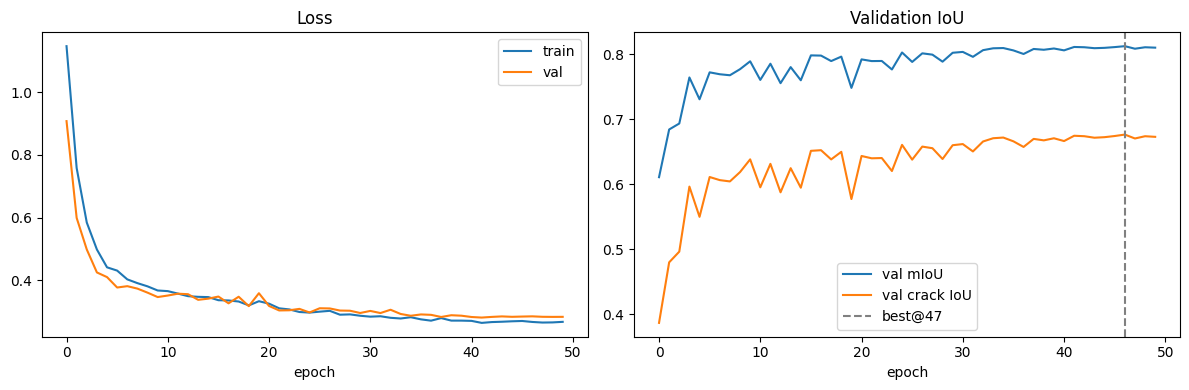

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist["train_loss"], label="train"); ax[0].plot(hist["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(hist["val_miou"], label="val mIoU"); ax[1].plot(hist["val_crack_iou"], label="val crack IoU")
ax[1].axvline(best_epoch-1, ls="--", c="gray", label=f"best@{best_epoch}")
ax[1].set_title("Validation IoU"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.savefig(WORK/f"{CONFIG['model']}_curves.png", dpi=110); plt.show()

## 8 · Task F — test-set evaluation (held-out, never seen in training/val)
We load the best checkpoint and evaluate on the test split with **horizontal-flip TTA** (average logits of the
image and its h-flip). We report **every required metric**: mIoU, per-class IoU, overall pixel accuracy, mean
pixel accuracy, Dice, and the pixel-level **confusion matrix**.

In [9]:
model.load_state_dict(torch.load(best_path, map_location=DEVICE)["model"]); model.eval()

@torch.no_grad()
def predict_tta(images):
    with mk_ac():
        l1 = infer_logits(model, images)
        l2 = torch.flip(infer_logits(model, torch.flip(images, dims=[3])), dims=[3])
    return ((torch.softmax(l1,1) + torch.softmax(l2,1)) / 2)

cm = ConfMat(NUM_CLASSES); per_img = {}
for images, masks, sids in test_loader:
    images = images.to(DEVICE)
    prob = predict_tta(images); pred = prob.argmax(1).cpu()
    cm.update(pred, masks)
    for b in range(images.size(0)):
        per_img[sids[b]] = per_image_iou(pred[b], masks[b], cls=1)
met = cm.compute()
crack_iou = met["iou"][1]; crack_dice = met["dice"][1]
print(f"=== Task F — {CONFIG['model']} test metrics ===")
print(f"mIoU               : {met['miou']:.4f}")
for i, c in enumerate(CLASS_NAMES): print(f"  IoU[{c}]         : {met['iou'][i]:.4f}")
print(f"Pixel accuracy     : {met['pixel_acc']:.4f}")
print(f"Mean pixel accuracy: {met['mean_pixel_acc']:.4f}")
print(f"Mean Dice          : {met['mdice']:.4f}  | crack Dice: {crack_dice:.4f}")

=== Task F — SegFormer-B0 test metrics ===
mIoU               : 0.8181
  IoU[background]         : 0.9492
  IoU[crack]         : 0.6869
Pixel accuracy     : 0.9543
Mean pixel accuracy: 0.9436
Mean Dice          : 0.8942  | crack Dice: 0.8144


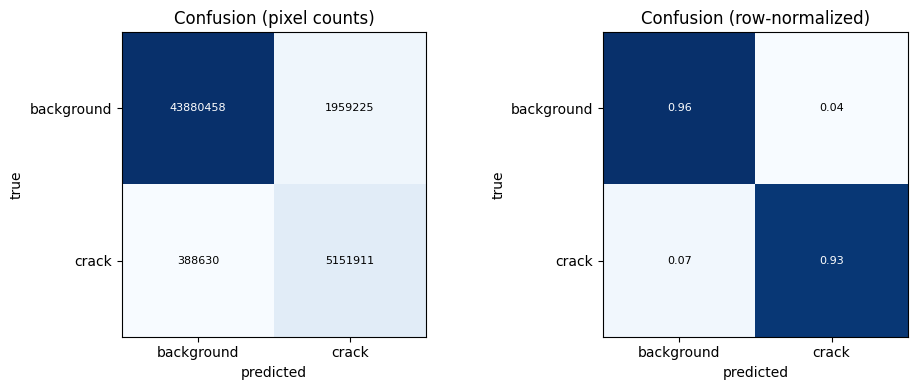

In [10]:
M = cm.mat.numpy(); Mn = M / M.sum(1, keepdims=True).clip(min=1)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for a, data, ttl, fmt in [(ax[0], M, "Confusion (pixel counts)", "d"), (ax[1], Mn, "Confusion (row-normalized)", ".2f")]:
    im = a.imshow(data, cmap="Blues"); a.set_xticks(range(NUM_CLASSES)); a.set_yticks(range(NUM_CLASSES))
    a.set_xticklabels(CLASS_NAMES); a.set_yticklabels(CLASS_NAMES); a.set_xlabel("predicted"); a.set_ylabel("true"); a.set_title(ttl)
    for r in range(NUM_CLASSES):
        for cc in range(NUM_CLASSES):
            a.text(cc, r, format(data[r,cc], fmt), ha="center", va="center",
                   color="white" if data[r,cc] > data.max()*0.5 else "black", fontsize=8)
plt.tight_layout(); plt.savefig(WORK/f"{CONFIG['model']}_confusion.png", dpi=110); plt.show()

## 9 · Task G — error analysis
**Worst images:** the test images with the lowest per-image crack IoU, shown as image / GT / prediction.
**Confused classes:** for a binary task the only confusable pair is background↔crack — the confusion matrix
above tells us whether errors are dominated by **false negatives** (missed thin cracks → low recall) or
**false positives** (texture/shadows called crack → low precision). We also save the per-image IoUs so NB3
(Task H) can test whether the three models fail on the **same** images.

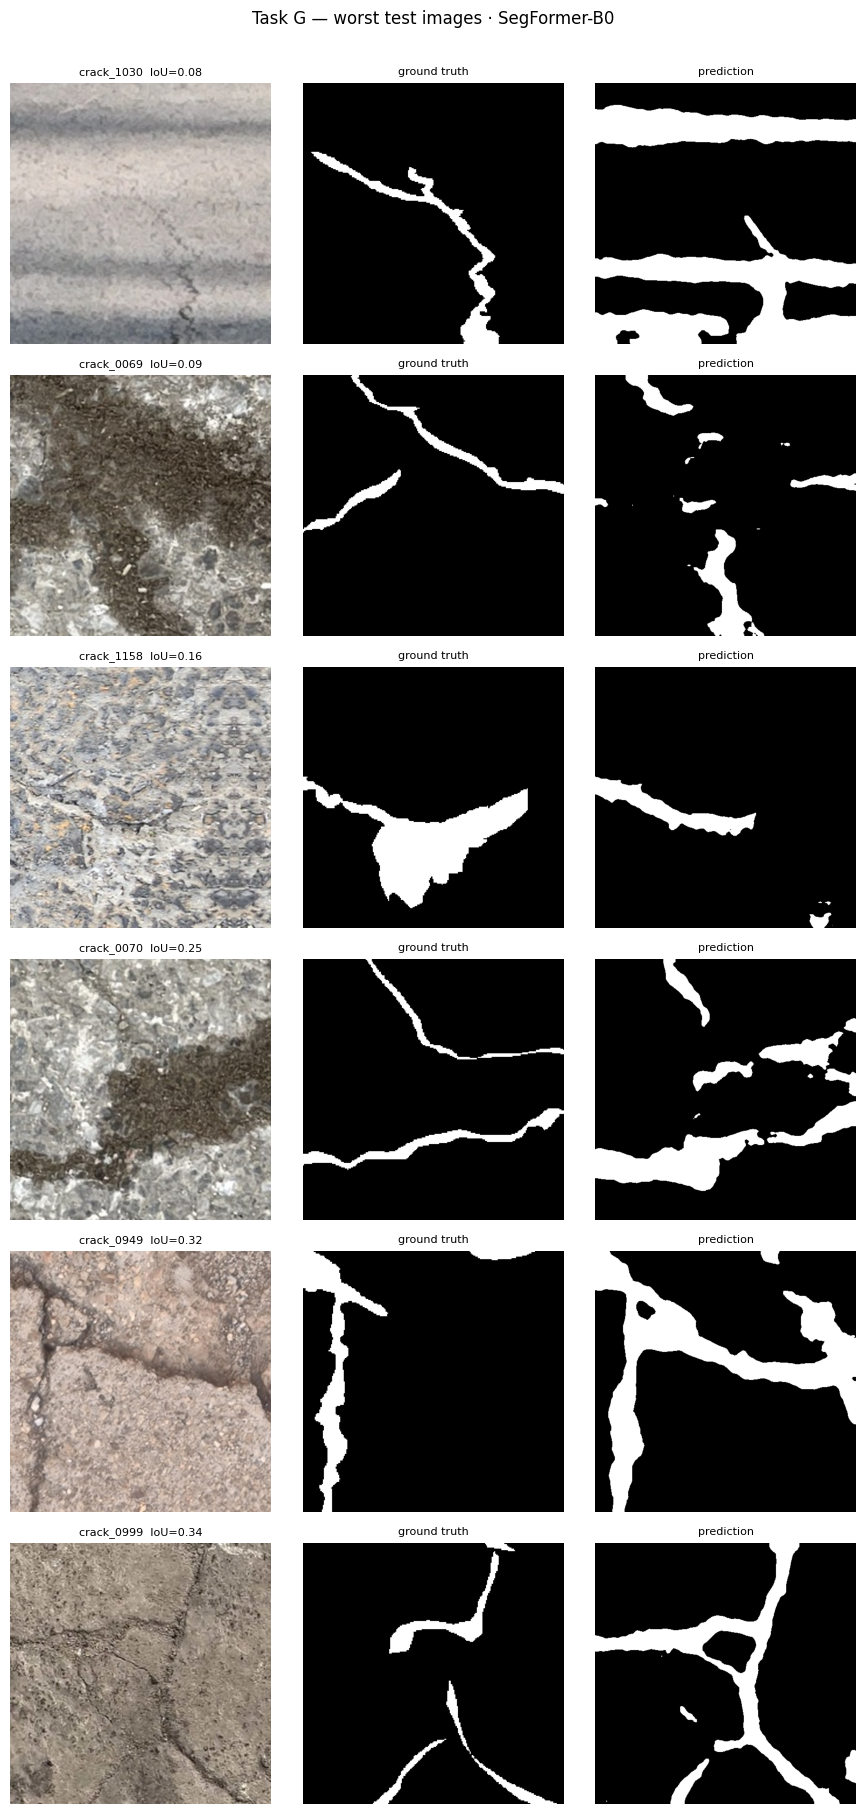

false positives (bg->crack): 1,959,225 px | false negatives (crack->bg): 388,630 px
dominant error: false positives (over-segmentation, precision-limited)


In [11]:
valid = {k: v for k, v in per_img.items() if not math.isnan(v)}
worst = sorted(valid, key=valid.get)[:6]
rec = {r["sample_id"]: r for r in split["test"]}
fig, ax = plt.subplots(len(worst), 3, figsize=(9, 3*len(worst))); ax = np.atleast_2d(ax)
for i, sid in enumerate(worst):
    r = rec[sid]
    img = np.array(Image.open(PATH_BY_NAME[r["image"]]).convert("RGB"))
    gt  = (np.array(Image.open(MASK_BY_NAME[r["mask"]])) > 0).astype(np.uint8)
    x = eval_aug(image=img, mask=gt)["image"].unsqueeze(0).to(DEVICE)
    pr = predict_tta(x).argmax(1)[0].cpu().numpy()
    ax[i,0].imshow(img); ax[i,0].set_title(f"{sid}  IoU={valid[sid]:.2f}", fontsize=8)
    ax[i,1].imshow(gt, cmap="gray"); ax[i,1].set_title("ground truth", fontsize=8)
    ax[i,2].imshow(pr, cmap="gray"); ax[i,2].set_title("prediction", fontsize=8)
    for a in ax[i]: a.axis("off")
plt.suptitle(f"Task G — worst test images · {CONFIG['model']}", y=1.005)
plt.tight_layout(); plt.savefig(WORK/f"{CONFIG['model']}_worst.png", dpi=100); plt.show()

fp = int(cm.mat[0,1]); fn = int(cm.mat[1,0])
print(f"false positives (bg->crack): {fp:,} px | false negatives (crack->bg): {fn:,} px")
print("dominant error:", "false negatives (missed cracks, recall-limited)" if fn > fp
      else "false positives (over-segmentation, precision-limited)")

## 10 · Summary — append metrics to the shared `results.json` (used by NB3 Task H)
We **merge** into any existing `results.json` (never overwrite the other models' entries) and store per-image
test IoUs + the confusion matrix so NB3 can build the final comparison.

In [12]:
rp = WORK/"results.json"
results = json.load(open(rp)) if rp.exists() else {}
results[CONFIG["model"]] = dict(
    model=CONFIG["model"], params_M=round(n_params,2),
    miou=met["miou"], per_class_iou=met["iou"], class_names=CLASS_NAMES,
    pixel_acc=met["pixel_acc"], mean_pixel_acc=met["mean_pixel_acc"],
    mdice=met["mdice"], per_class_dice=met["dice"],
    crack_iou=crack_iou, crack_dice=crack_dice,
    train_minutes=round(train_min,1), best_epoch=int(best_epoch), epochs=EPOCHS,
    config=CONFIG, confusion=cm.mat.tolist(),
    per_image_crack_iou=valid,
)
json.dump(results, open(rp, "w"), indent=2)
print("results.json now has models:", list(results.keys()))
print(f"\n### {CONFIG['model']} — FINAL: mIoU {met['miou']:.4f} | crack IoU {crack_iou:.4f} | "
      f"pixel-acc {met['pixel_acc']:.4f} | {train_min:.1f} min | {n_params:.1f}M params")

results.json now has models: ['SegFormer-B0']

### SegFormer-B0 — FINAL: mIoU 0.8181 | crack IoU 0.6869 | pixel-acc 0.9543 | 18.5 min | 3.7M params


### NB2 complete
Trained **SegFormer-B0** ≥50 epochs on NB0's leakage-safe split, reported all Task-F metrics + confusion matrix,
and did Task-G error analysis. Metrics are appended to `results.json`. **Commit** this notebook so NB3 can pull
`results.json` and `best.pt` for the final comparison (Task H).